imported python libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

In [2]:
import os

os.chdir(r"C:\Users\USER\Desktop\krishna priya\diamond price_project")

print("Current Dir:", os.getcwd())

Current Dir: C:\Users\USER\Desktop\krishna priya\diamond price_project


importing data

In [3]:
data = pd.read_csv("../csv/price.csv")


data summary

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53943 non-null  int64  
 1   carat       53943 non-null  float64
 2   cut         53943 non-null  object 
 3   color       53943 non-null  object 
 4   clarity     53943 non-null  object 
 5   depth       53943 non-null  float64
 6   table       53943 non-null  float64
 7   price       53943 non-null  int64  
 8   x           53943 non-null  float64
 9   y           53943 non-null  float64
 10  z           53943 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [5]:
data.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000
mean,26972.000000,0.797935,61.749322,57.457251,3932.734294,5.731158,5.734526,3.538730
std,15572.147122,0.473999,1.432626,2.234549,3989.338447,1.121730,1.142103,0.705679
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13486.500000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26972.000000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40457.500000,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.040000
max,53943.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Data cleaning

#checking duplicate rows

In [6]:
# remove duplicates
data.duplicated().sum()

np.int64(0)

Null values

In [7]:
data.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [8]:
data.isnull().sum().sum()

np.int64(0)

In [9]:
data.fillna(0,inplace=True)

save the cleaned data

In [10]:
data.to_csv("cleaned_price.csv",index=False)

data visualization

In [11]:
from src.utils import save_plot

Bar chart

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\cut_distribution.png


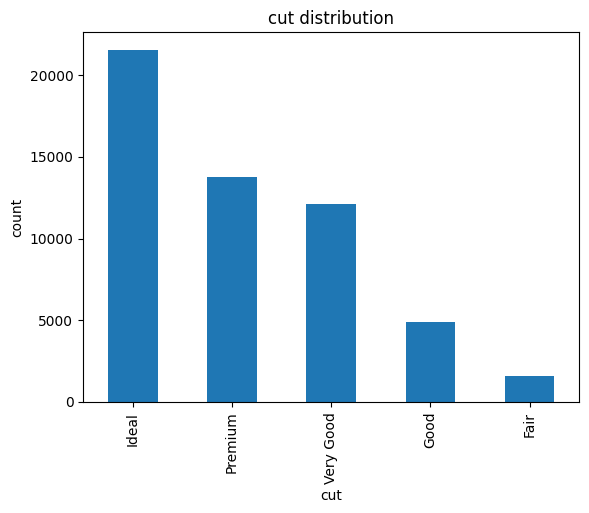

In [12]:
data['cut'].value_counts().plot(kind='bar')
plt.title('cut distribution')
plt.xlabel('cut')
plt.ylabel('count')
save_plot("cut_distribution.png", plt)
plt.show()

pie chart

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\cut_pie.png


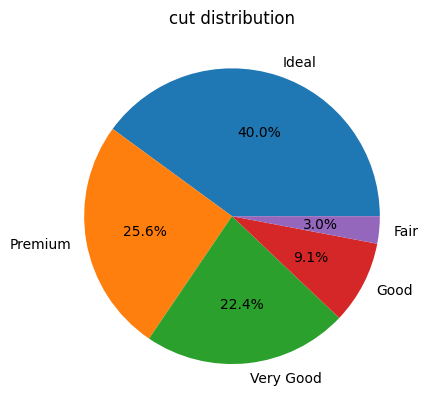

In [13]:
data['cut'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('cut distribution')
plt.ylabel('')
save_plot("cut_pie.png", plt)
plt.show()

Histogram

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\price_hist.png


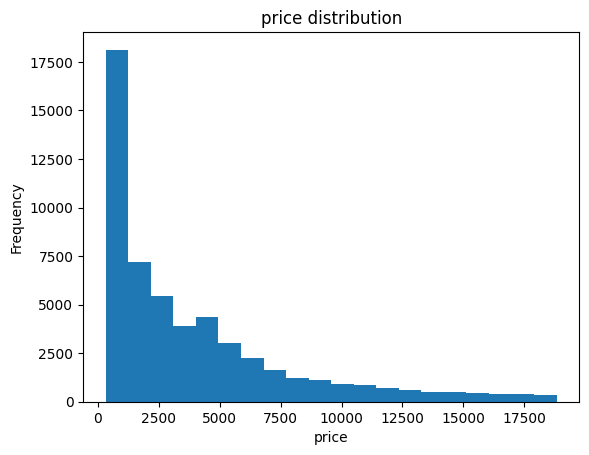

In [14]:
data['price'].plot(kind='hist',bins=20)
plt.title('price distribution')
plt.xlabel('price')
save_plot("price_hist.png", plt)
plt.show()

In [15]:
print(len(data))

53943


Scatter plot

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\scatter.png


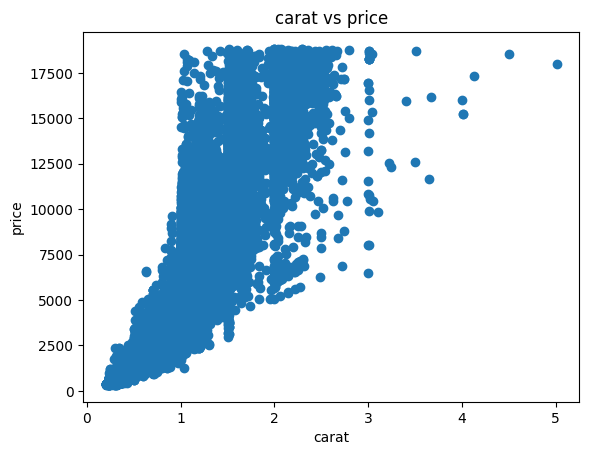

In [16]:
plt.scatter(data['carat'], data['price'])
plt.title('carat vs price')
plt.xlabel('carat')
plt.ylabel('price')
save_plot("scatter.png", plt)
plt.show()

Correlation heatmap

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\heatmap.png


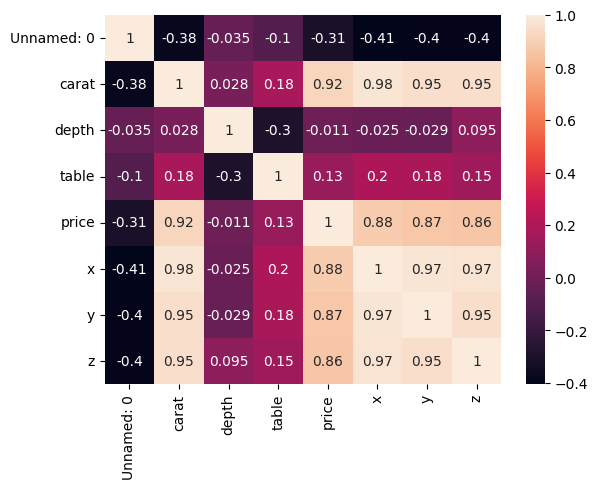

In [17]:
sns.heatmap(data.corr(numeric_only=True),annot=True)
save_plot("heatmap.png", plt)
plt.show()

Box plot

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\boxplot.png


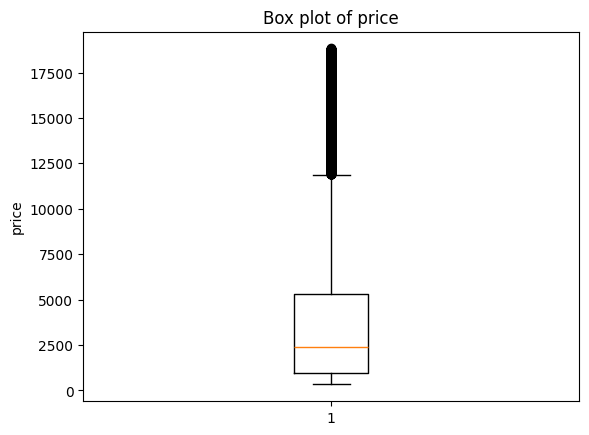

In [18]:
plt.boxplot(data['price'])
plt.title('Box plot of price')
plt.ylabel('price')
save_plot("boxplot.png", plt)
plt.show()

Line chart

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\line.png


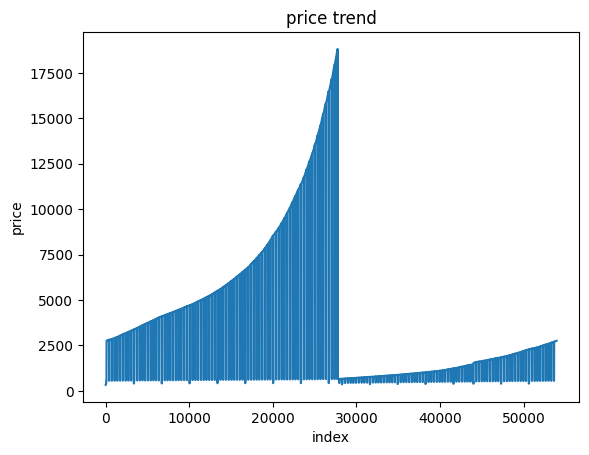

In [19]:
data['price'].plot(kind='line')
plt.title('price trend')
plt.xlabel('index')
plt.ylabel('price')
save_plot("line.png", plt)
plt.show()

Area chart

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\density.png


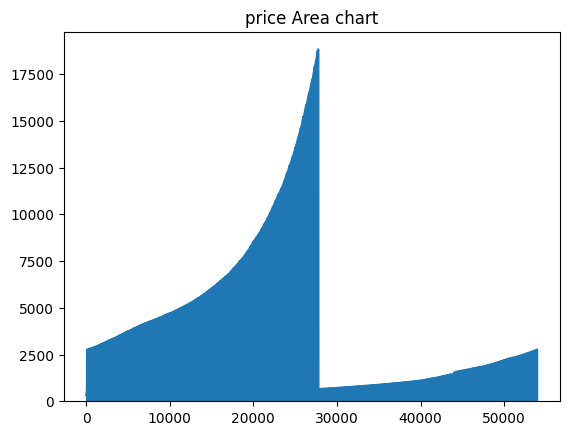

In [20]:
data['price'].plot(kind='area')
plt.title('price Area chart')
save_plot("density.png", plt)
plt.show()

Density plot

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\density.png


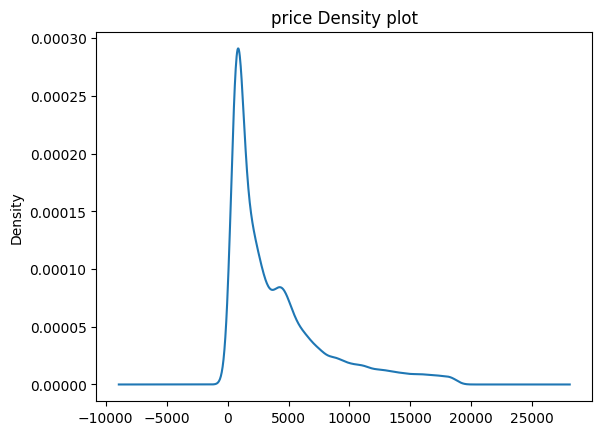

In [21]:
data['price'].plot(kind='density')
plt.title('price Density plot')
save_plot("density.png", plt)
plt.show()

Violin plot

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\Violin.png


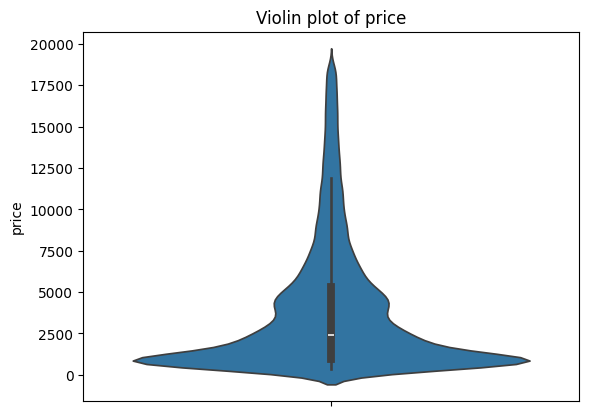

In [22]:
sns.violinplot(y=data['price'])
plt.title('Violin plot of price')
save_plot("Violin.png",plt)
plt.show()

In [23]:
import sys
sys.path.append(r"C:\Users\USER\Desktop\krishna priya\diamond price_project")

from src.utils import save_plot

pair plot

Plot saved: C:\Users\USER\Desktop\krishna priya\diamond price_project\artifacts\plots\pairplot.png


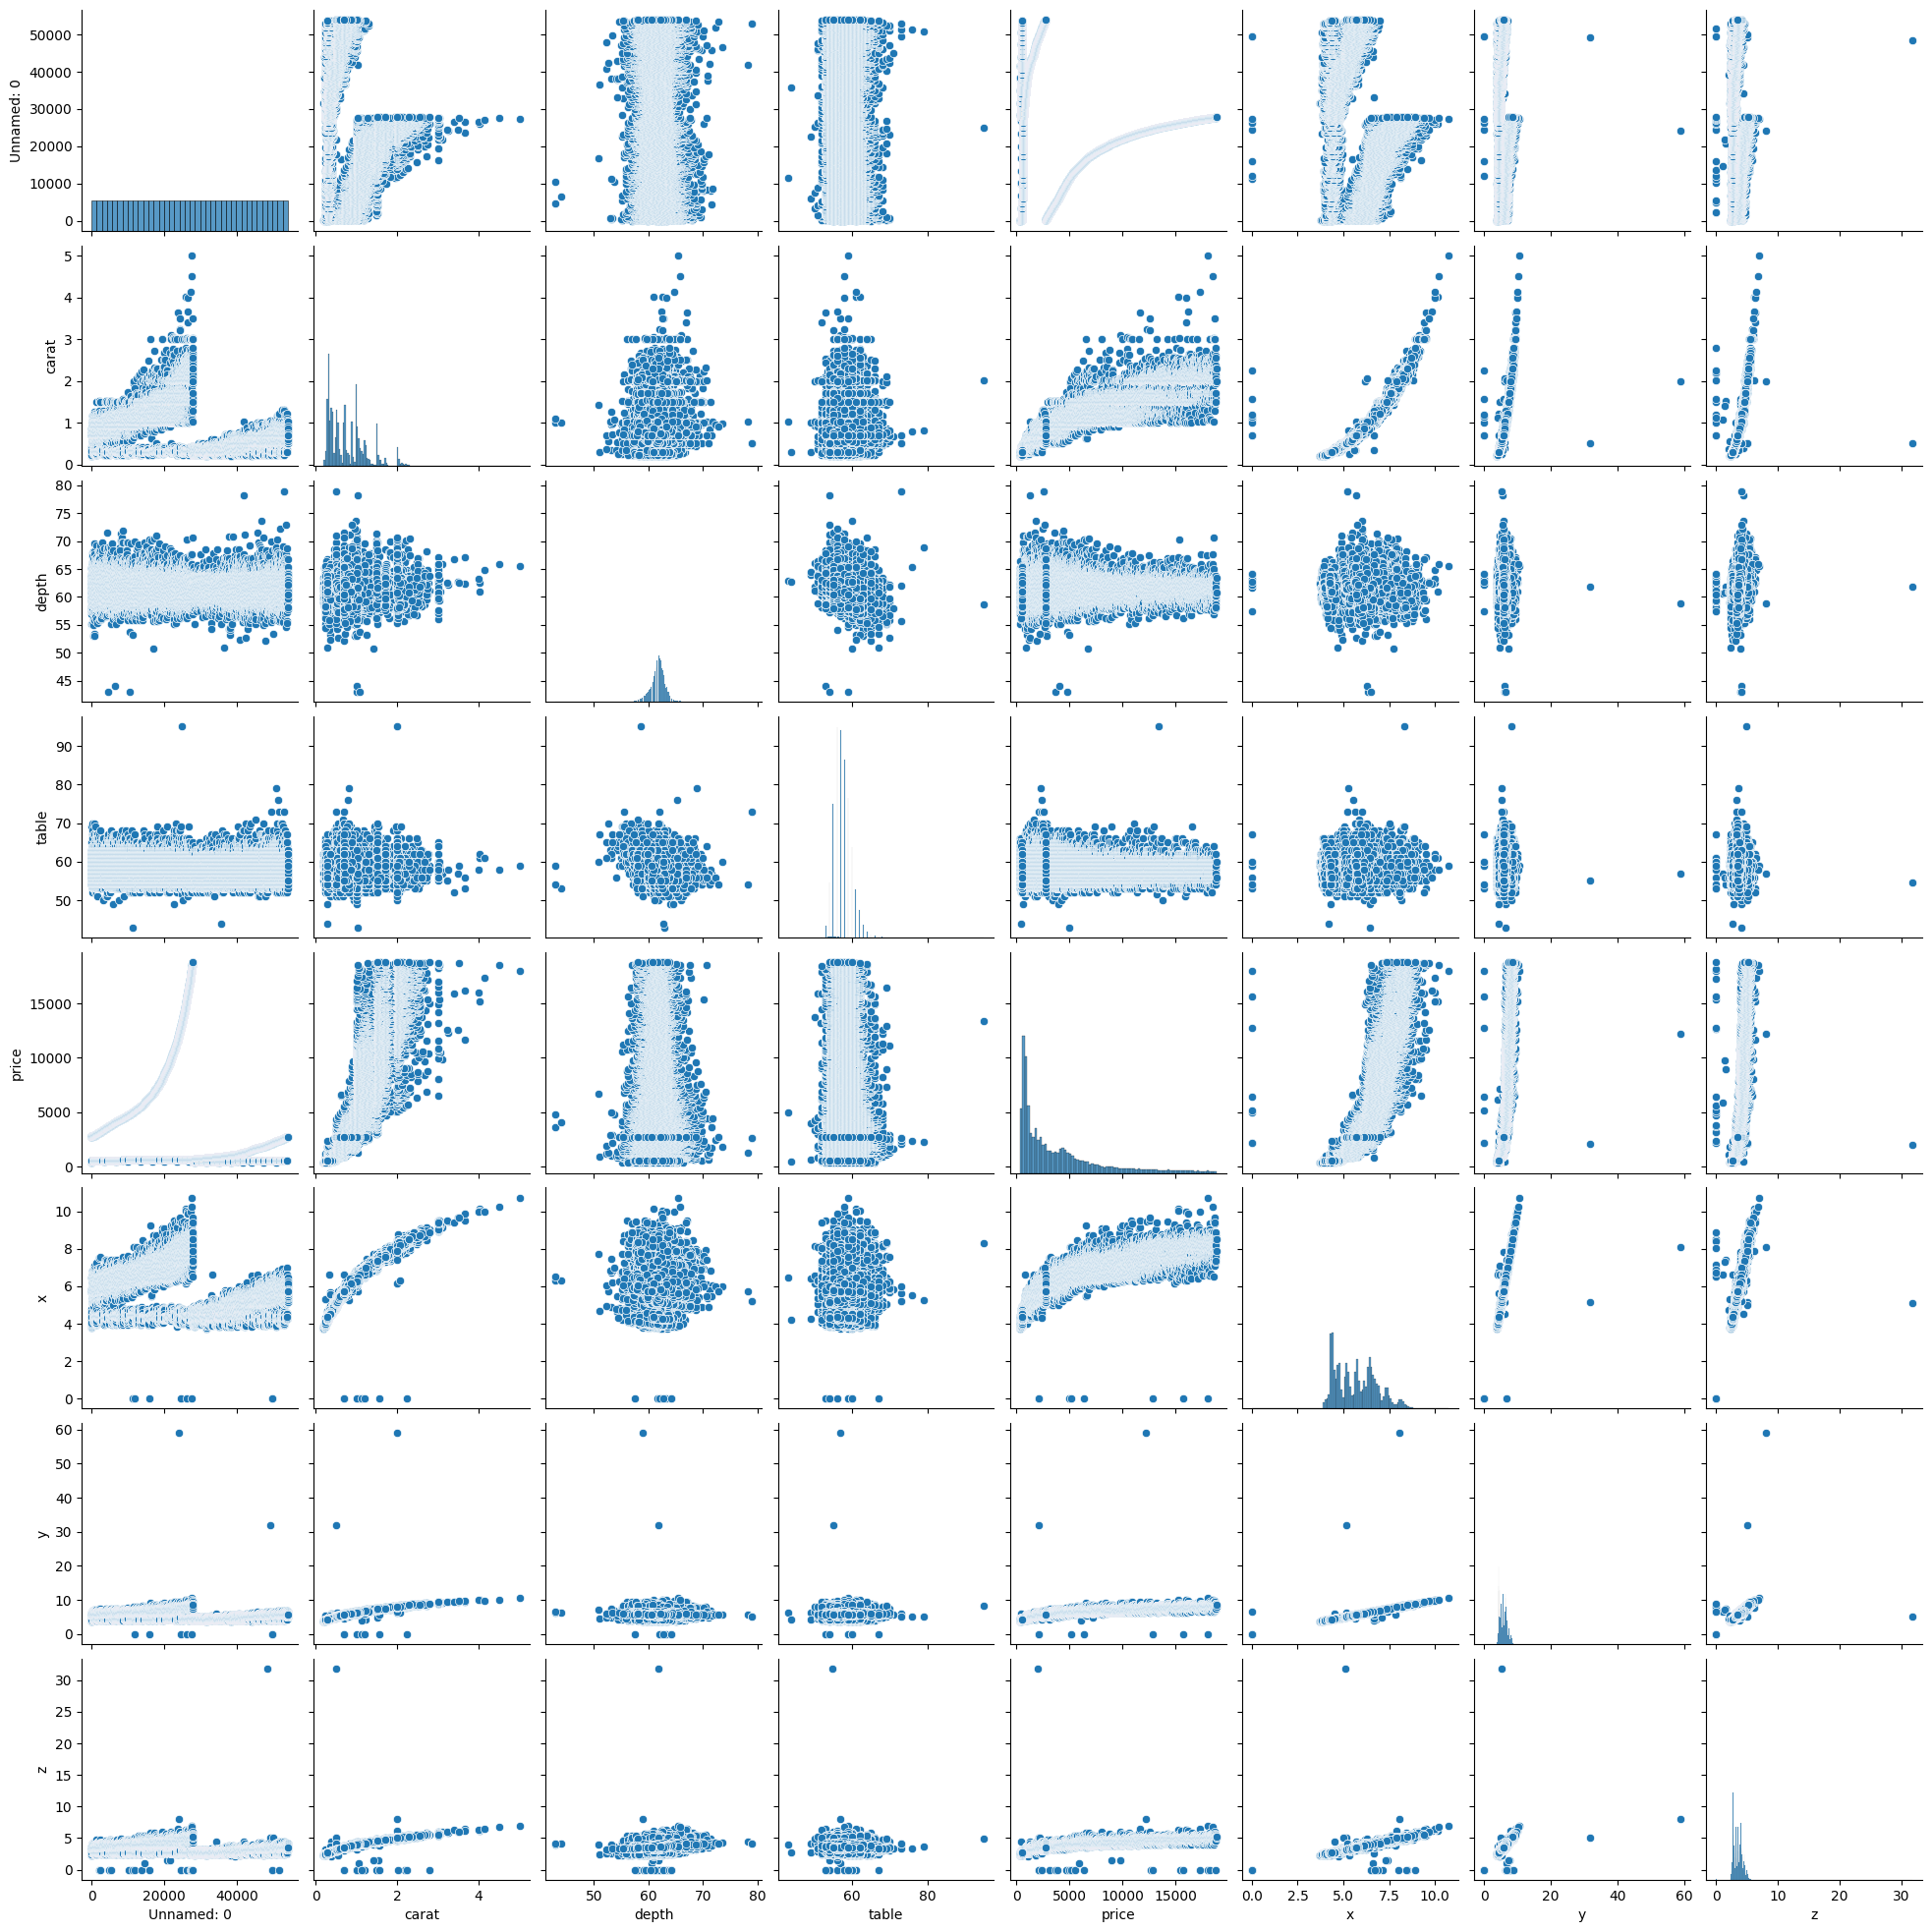

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data)

save_plot("pairplot.png", plt)
plt.show()
plt.close()

Feature Engineering

price per carat

In [25]:
data['price_per_carat']=data['price']/data['carat']
data.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z,price_per_carat
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,1417.391304
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,1552.380952
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,1421.739130
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,1151.724138
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,1080.645161


carat category

In [26]:
data['carat_category']=pd.cut(data['carat'],bins=3,labels=['small','medium','large'])
print(data[['carat','carat_category']].head(20))

    carat carat_category
0    0.23          small
1    0.21          small
2    0.23          small
3    0.29          small
4    0.31          small
5    0.24          small
6    0.24          small
7    0.26          small
8    0.22          small
9    0.23          small
10   0.30          small
11   0.23          small
12   0.22          small
13   0.31          small
14   0.20          small
15   0.32          small
16   0.30          small
17   0.30          small
18   0.30          small
19   0.30          small


Save feature engineering

In [27]:
data.to_csv('diamond_feature_engineered.csv',index=False)

Data visualization after feature engineering

price per carat Histogram

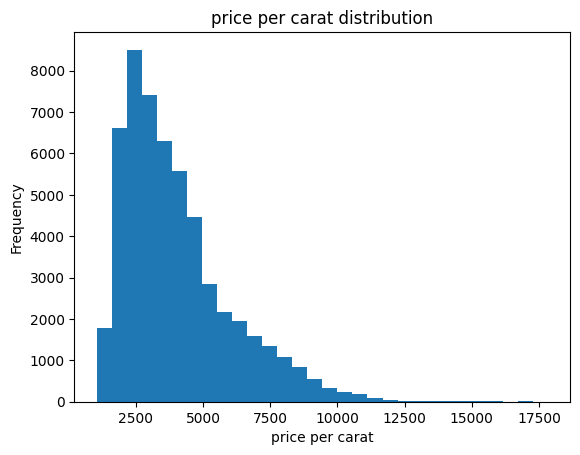

In [28]:
data['price_per_carat'].plot(kind='hist',bins=30)
plt.title('price per carat distribution')
plt.xlabel('price per carat')
plt.show()

Carat category bar chart

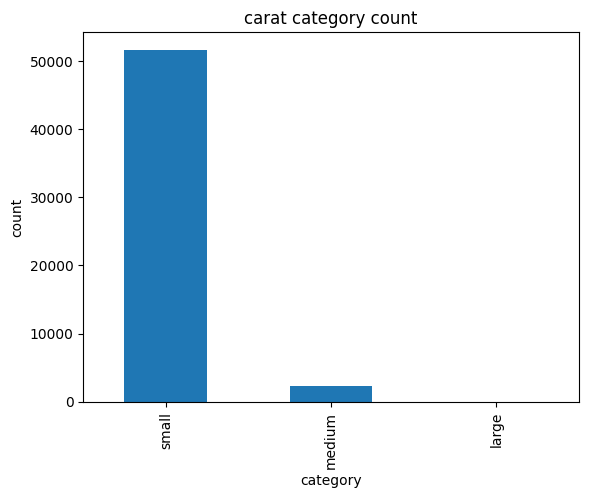

In [29]:
data['carat_category'].value_counts().plot(kind='bar')
plt.title('carat category count')
plt.xlabel('category')
plt.ylabel('count')
plt.show()


Box plot for price per carat

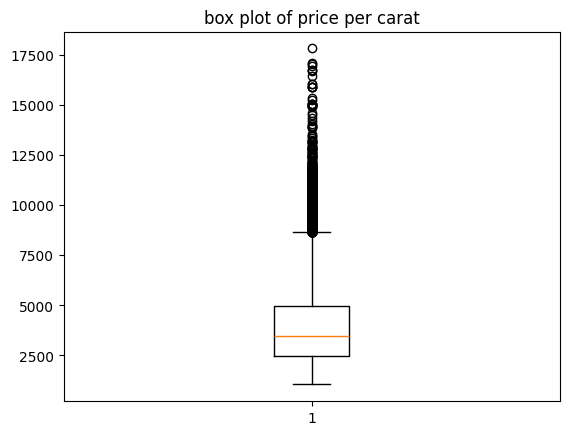

In [30]:
plt.boxplot(data['price_per_carat'])
plt.title('box plot of price per carat')
plt.show()

Carat category pie chart

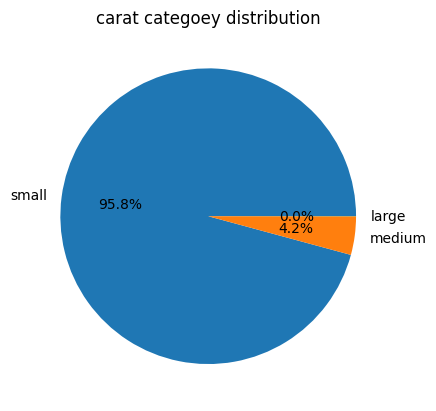

In [31]:
data['carat_category'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('carat categoey distribution')
plt.ylabel('')
plt.show()


Scatter plot(carat vs price per carat)

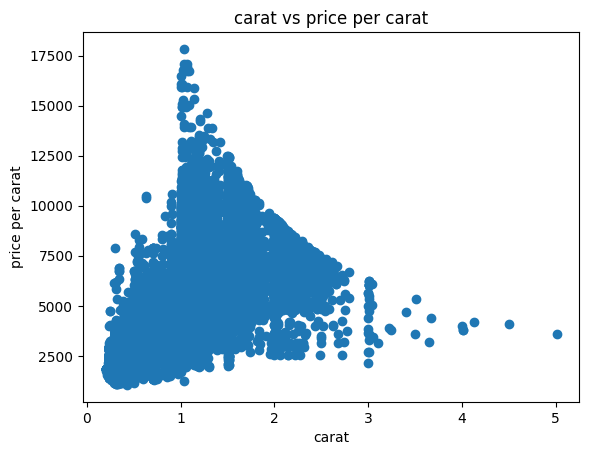

In [32]:
plt.scatter(data['carat'],data['price_per_carat'])
plt.title('carat vs price per carat')
plt.xlabel('carat')
plt.ylabel('price per carat')
plt.show()

Feature selection

In [33]:
features=['carat','depth','table','x','y','z']
x = data[features]
y = data['price']

Remove unwanted columns

In [34]:
data = data.drop(['Unnamed: 0'], axis=1)

Data Split/Partition

In [35]:
from sklearn.model_selection import train_test_split

Split Feature And Target

In [36]:
x=data[['carat', 'depth', 'table', 'x', 'y', 'z']]

Train Test Split

In [37]:
X_train, X_test, y_train, y_test=train_test_split( x,y,test_size=0.2,random_state=42)


Check Data Shape

In [38]:
print("x_train shape:",X_train.shape)
print("x_test shape:",X_test.shape)


x_train shape: (43154, 6)
x_test shape: (10789, 6)


Data Transformation

Label Encorder

In [39]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['cut']=le.fit_transform(data['cut'])
data['color']=le.fit_transform(data['color'])
data['clarity']=le.fit_transform(data['clarity'])

Display Transformed Data

In [40]:
print(data.head())

   carat  cut  color  clarity  depth  table  price     x     y     z  \
0   0.23    2      1        3   61.5   55.0    326  3.95  3.98  2.43   
1   0.21    3      1        2   59.8   61.0    326  3.89  3.84  2.31   
2   0.23    1      1        4   56.9   65.0    327  4.05  4.07  2.31   
3   0.29    3      5        5   62.4   58.0    334  4.20  4.23  2.63   
4   0.31    1      6        3   63.3   58.0    335  4.34  4.35  2.75   

   price_per_carat carat_category  
0      1417.391304          small  
1      1552.380952          small  
2      1421.739130          small  
3      1151.724138          small  
4      1080.645161          small  


Model Initialization

Import Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression

Initialize the model

In [42]:
model=LinearRegression()
print("LinearRegression model initialized successfully")

LinearRegression model initialized successfully


##  Model Traning

Train Random Forest Regressuin Model

In [43]:
model.fit(X_train, y_train)

LinearRegression()

Train Logistic Regression Model 

In [44]:
from sklearn.svm import SVR 
svm_model = SVR()

In [45]:
svm_model.fit(X_train, y_train)

SVR()

## Model Evaluation

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Make Predictions

In [47]:
y_pred = svm_model.predict(X_test)

Calculate Evaluation Metrics

In [48]:
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("model evaluation results")
print("mean absolute error:", mae)
print("mean squared error:",mse)
print("r2 score:",r2)

model evaluation results
mean absolute error: 2708.198777095052
mean squared error: 17366428.279667042
r2 score: -0.11229570590997695


## Model Visualization

Actual vs Predicted values

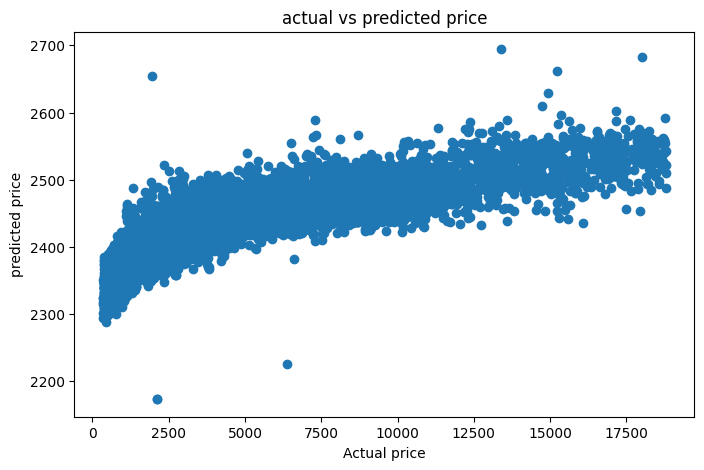

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual price")
plt.ylabel("predicted price")
plt.title("actual vs predicted price")
plt.show()

## Model Deployment

Model Initialization

In [50]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

Save Model

Model Traning

In [51]:
model.fit(X_train, y_train)

LinearRegression()

In [52]:
import joblib
joblib.dump(model,"diamond_price_model.pkl")
print("Model Saaved Successfully")

Model Saaved Successfully


Model Prediction

In [53]:
y_pred=model.predict(X_test)
print("predicted values:")
print(y_pred[:5])

predicted values:
[  198.8328961   7185.508113     475.29975967  1513.66460254
 10009.88672645]


In [54]:
import os
print(os.listdir())

['artifacts', 'cleaned_price.csv', 'data', 'diamond_feature_engineered.csv', 'diamond_price_model.pkl', 'main.py', 'src']


In [55]:
print(model)

LinearRegression()


In [56]:
import os

print("Current Working Directory:")
print(os.getcwd())


Current Working Directory:
C:\Users\USER\Desktop\krishna priya\diamond price_project
